<a href="https://colab.research.google.com/github/RenatFaiz/OOD-with-torch-uncertainty/blob/develop/torch_uncertainty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch-uncertainty

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.2/815.2 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:

In [1]:
import torch
import torchvision
from torch import nn, optim
from torch.optim import lr_scheduler
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn.functional as F
from torch_uncertainty.datamodules import CIFAR10DataModule
from torch_uncertainty.utils import TUTrainer
from torch_uncertainty.routines.classification import ClassificationRoutine
import os
import numpy as np
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
os.chdir('/content/drive/MyDrive/Colab Notebooks/AI Lab/Uncertainty')
os.getcwd()

'/content/drive/MyDrive/Colab Notebooks/AI Lab/Uncertainty'

## Model - CNN from [paper by Xia](https://arxiv.org/abs/2106.00445)

In [4]:
def call_bn(bn, x):
    return bn(x)

class CNN(nn.Module):
    def __init__(self, input_channel=3, n_outputs=10, dropout_rate=0.25, top_bn=False):
        self.dropout_rate = dropout_rate
        self.top_bn = top_bn
        super(CNN, self).__init__()
        self.c1=nn.Conv2d(input_channel,128,kernel_size=3,stride=1, padding=1)
        self.c2=nn.Conv2d(128,128,kernel_size=3,stride=1, padding=1)
        self.c3=nn.Conv2d(128,128,kernel_size=3,stride=1, padding=1)
        self.c4=nn.Conv2d(128,256,kernel_size=3,stride=1, padding=1)
        self.c5=nn.Conv2d(256,256,kernel_size=3,stride=1, padding=1)
        self.c6=nn.Conv2d(256,256,kernel_size=3,stride=1, padding=1)
        self.c7=nn.Conv2d(256,512,kernel_size=3,stride=1, padding=0)
        self.c8=nn.Conv2d(512,256,kernel_size=3,stride=1, padding=0)
        self.c9=nn.Conv2d(256,128,kernel_size=3,stride=1, padding=0)
        self.l_c1=nn.Linear(128,n_outputs)
        self.bn1=nn.BatchNorm2d(128)
        self.bn2=nn.BatchNorm2d(128)
        self.bn3=nn.BatchNorm2d(128)
        self.bn4=nn.BatchNorm2d(256)
        self.bn5=nn.BatchNorm2d(256)
        self.bn6=nn.BatchNorm2d(256)
        self.bn7=nn.BatchNorm2d(512)
        self.bn8=nn.BatchNorm2d(256)
        self.bn9=nn.BatchNorm2d(128)

    def forward(self, x,):
        h=x
        h=self.c1(h)
        h=F.leaky_relu(call_bn(self.bn1, h), negative_slope=0.01)
        h=self.c2(h)
        h=F.leaky_relu(call_bn(self.bn2, h), negative_slope=0.01)
        h=self.c3(h)
        h=F.leaky_relu(call_bn(self.bn3, h), negative_slope=0.01)
        h=F.max_pool2d(h, kernel_size=2, stride=2)
        h=F.dropout2d(h, p=self.dropout_rate)

        h=self.c4(h)
        h=F.leaky_relu(call_bn(self.bn4, h), negative_slope=0.01)
        h=self.c5(h)
        h=F.leaky_relu(call_bn(self.bn5, h), negative_slope=0.01)
        h=self.c6(h)
        h=F.leaky_relu(call_bn(self.bn6, h), negative_slope=0.01)
        h=F.max_pool2d(h, kernel_size=2, stride=2)
        h=F.dropout2d(h, p=self.dropout_rate)

        h=self.c7(h)
        h=F.leaky_relu(call_bn(self.bn7, h), negative_slope=0.01)
        h=self.c8(h)
        h=F.leaky_relu(call_bn(self.bn8, h), negative_slope=0.01)
        h=self.c9(h)
        h=F.leaky_relu(call_bn(self.bn9, h), negative_slope=0.01)
        h=F.avg_pool2d(h, kernel_size=h.data.shape[2])

        h = h.view(h.size(0), h.size(1))
        logit=self.l_c1(h)
        if self.top_bn:
            logit=call_bn(self.bn_c1, logit)
        return logit

In [5]:
num_classes = 10
max_epochs = 25
batch_size = 32
eval_ood = True
num_workers = 2 # recommended

In [6]:
class NLoss(nn.Module):
    def __init__(self, label_smoothing=0.1, num_classes=num_classes):
        super(NLoss, self).__init__()
        self.label_smoothing = label_smoothing
        self.num_classes = num_classes
        self.inv_smoothing = 1.0 - label_smoothing  # Probability for the correct class
        self.smoothing = label_smoothing / (num_classes - 1)  # Probability for incorrect classes

    def forward(self, x, y):
        """
        x: Model output (logits + log variance)
            - x[:, :self.num_classes]: Logits for class probabilities (h)
            - x[:, self.num_classes:]: Logarithmic variance (s)
        y: Labels
        """
        # Split the model output into predictions (h) and log variance (s)
        logits = x[:, :self.num_classes]  # Predictions (h)
        log_var = x[:, self.num_classes:]  # Logarithmic variance (s)

        # Apply label smoothing to the one-hot encoded labels
        with torch.no_grad():
            yoh = torch.zeros_like(logits)
            yoh.fill_(self.smoothing / (self.num_classes - 1))
            yoh.scatter_(1, y.data.unsqueeze(1), self.inv_smoothing)

        # Compute the squared differences between predictions and smoothed labels
        squared_diff = torch.pow(yoh - logits, 2)  # (y_k - h_k)^2

        # Compute the exponential of the negative log variance (e^{-s})
        exp_neg_log_var = torch.exp(-log_var)

        # Compute the first term of the loss: e^{-s} * sum((y_k - h_k)^2)
        term1 = exp_neg_log_var * squared_diff.sum(dim=1)

        # Compute the second term of the loss: N * s
        term2 = self.num_classes * log_var

        # Combine the terms and compute the mean over the batch
        loss = (term1 + term2).mean()

        return loss

In [ ]:
# Experiment - NLoss
model_cs = CNN(input_channel=3, n_outputs=num_classes+1)
routine = ClassificationRoutine(
    model_cs,
    num_classes=num_classes+1,
    eval_ood=eval_ood,
    loss=NLoss(num_classes=num_classes),
    optim_recipe=optim.Adam(model_cs.parameters(), lr=1e-3),
    log_plots=True,
    save_in_csv=True
)
# тип модуля
dm = CIFAR10DataModule(root="data", batch_size=batch_size, num_workers=num_workers, eval_ood=eval_ood)
trainer = TUTrainer(max_epochs=max_epochs)

# Обучение модели
trainer.fit(routine, dm)

# Тестирование модели
test_results = trainer.test(routine, dm)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


Files already downloaded and verified
Files already downloaded and verified
Using downloaded and verified file: data/test_32x32.mat


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | model            | CNN              | 4.4 M  | train
1 | loss             | NLoss            | 0      | train
2 | format_batch_fn  | Identity         | 0      | train
3 | val_cls_metrics  | MetricCollection | 0      | train
4 | test_cls_metrics | MetricCollection | 0      | train
5 | test_id_entropy  | Entropy          | 0      | train
6 | test_ood_metrics | MetricCollection | 0      | train
7 | test_ood_entropy | Entropy          | 0      | train
8 | mixup            | Identity         | 0      | train
--------------------------------------------------------------
4.4 M     Trainable params
0         Non-trainable params
4.4 M     Total params
17.739    Total estimated model params size (MB)
49        Modules in train mode
0   

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

INFO: `Trainer.fit` stopped: `max_epochs=25` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=25` reached.


Files already downloaded and verified
Files already downloaded and verified
Using downloaded and verified file: data/test_32x32.mat


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃      Classification       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     Acc      │          90.270%          │
│    Brier     │          0.71909          │
│   Entropy    │          2.25772          │
│     NLL      │          1.64980          │
└──────────────┴───────────────────────────┘
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃        Calibration        ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     ECE      │          0.70093          │
│     aECE     │          0.70093          │
└──────────────┴───────────────────────────┘
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃       OOD Detection       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     AUPR     │          91.017%          │
│    AUROC     │          84.657%          │
│   Entropy    │          2.28438          │
│    FPR95     │          49.060%          │
└──────────────┴───────────────────────────┘
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃ Selective Classification  ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    AUGRC     │          1.509%           │
│     AURC     │          2.153%           │
│  Cov@5Risk   │          88.750%          │
│  Risk@80Cov  │          2.812%           │
└──────────────┴───────────────────────────┘

In [ ]:
# Сохранение модели с состоянием
checkpoint = {
    "model_state_dict": model_cs.state_dict(),
    "optimizer_state_dict": trainer.optimizers[0].state_dict(),  # Оптимизатор
}
torch.save(checkpoint, "model_checkpoint.pth")
print("Модель и параметры оптимизатора сохранены.")


Модель и параметры оптимизатора сохранены.


In [ ]:
# Сохранение весов модели

# Путь для сохранения модели
model_path = "model_cs.pth"

torch.save(model_cs.state_dict(), model_path)
print(f"Модель сохранена в {model_path}")


Модель сохранена в model_cs.pth


In [ ]:
# Сохранение результатов тестирования в csv
# test_results = trainer.test(routine, dm)
df = pd.DataFrame(test_results)
df.to_csv("test_results.csv", index=False)

print("Результаты тестирования сохранены в test_results.csv")

Files already downloaded and verified
Files already downloaded and verified
Using downloaded and verified file: data/test_32x32.mat


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃      Classification       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     Acc      │          90.130%          │
│    Brier     │          0.71903          │
│   Entropy    │          2.25773          │
│     NLL      │          1.64962          │
└──────────────┴───────────────────────────┘
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃        Calibration        ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     ECE      │          0.69943          │
│     aECE     │          0.69943          │
└──────────────┴───────────────────────────┘
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃       OOD Detection       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     AUPR     │          91.006%          │
│    AUROC     │          84.690%          │
│   Entropy    │          2.28425          │
│    FPR95     │          49.755%          │
└──────────────┴───────────────────────────┘
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Test metric  ┃ Selective Classification  ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    AUGRC     │          1.513%           │
│     AURC     │          2.223%           │
│  Cov@5Risk   │          89.230%          │
│  Risk@80Cov  │          2.862%           │
└──────────────┴───────────────────────────┘

Результаты тестирования сохранены в test_results.csv


In [ ]:
# Загрузка результатов тестирования
if os.path.exists("test_results.csv"):
    df = pd.read_csv("test_results.csv")
    print("Загружены сохранённые результаты тестирования:")
    print(df)

Загружены сохранённые результаты тестирования:
   test/cal/ECE  test/cal/aECE  test/cls/Acc  test/cls/Brier  test/cls/NLL  \
0      0.699433       0.699433        0.9013        0.719028      1.649623   
1           NaN            NaN           NaN             NaN           NaN   

   test/sc/AUGRC  test/sc/AURC  test/sc/Cov@5Risk  test/sc/Risk@80Cov  \
0       0.015129      0.022229             0.8923            0.028625   
1            NaN           NaN                NaN                 NaN   

   test/cls/Entropy  ood/AUPR  ood/AUROC  ood/FPR95  ood/Entropy  
0          2.257726  0.910062   0.846901    0.49755          NaN  
1               NaN  0.910062   0.846901    0.49755     2.284252  


In [ ]:
# @title
# Создание объекта датамодуля
dm = CIFAR10DataModule(root="data", batch_size=batch_size, num_workers=num_workers, eval_ood=eval_ood)

# Подготовка данных (если это не было сделано)
dm.prepare_data()  # Загружает данные (нужно только 1 раз)
dm.setup(stage="test")  # Готовит тестовый набор

# Проверяем тип dm.test_dataloader()
print("Type of dm.test_dataloader():", type(dm.test_dataloader()))

# Проверяем длину dm.test_dataloader()
try:
    test_loader = dm.test_dataloader()
    print("Length of dm.test_dataloader():", len(test_loader))

    # Если длина больше 0, извлекаем первый батч
    if len(test_loader) > 0:
        first_batch = next(iter(test_loader))
        print("First batch structure:", type(first_batch), len(first_batch))
    else:
        print("Test DataLoader is empty.")

except AttributeError as e:
    print(f"Ошибка: {e}. Возможно, test_dataloader() отсутствует.")


In [7]:
# Создание экземпляра модели
model_cs = CNN(input_channel=3, n_outputs=num_classes+1)

# Создание оптимизатора перед загрузкой
optimizer = optim.Adam(model_cs.parameters(), lr=1e-3)

In [8]:
# Загрузка чекпоинта модели перед тестированием:
checkpoint = torch.load("model_checkpoint.pth", weights_only=False)

# Загружаем веса модели
model_cs.load_state_dict(checkpoint["model_state_dict"])

# ! Для дообучения - загружаем состояние оптимизатора (если оно есть в чекпойнте)
# if "optimizer_state_dict" in checkpoint:
#     optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
#     print("Состояние оптимизатора загружено.")

model_cs.eval()  # Выключает Dropout и нормализацию BatchNorm
print("Модель и параметры оптимизатора загружены.")


Модель и параметры оптимизатора загружены.


In [9]:
# Проверяем, что веса загружены (сравниваем первые 5 значений)
print("First 5 weights before loading:", list(model_cs.parameters())[0].view(-1)[:5])
model_cs.load_state_dict(torch.load("model_checkpoint.pth")["model_state_dict"])
print("First 5 weights after loading:", list(model_cs.parameters())[0].view(-1)[:5])


First 5 weights before loading: tensor([ 0.2945, -0.2189, -0.0108, -0.4150,  0.0169], grad_fn=<SliceBackward0>)


<ipython-input-9-93ad4d951cc7>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_cs.load_state_dict(torch.load("model_checkpoint.pth")["model_state_dict"])


First 5 weights after loading: tensor([ 0.2945, -0.2189, -0.0108, -0.4150,  0.0169], grad_fn=<SliceBackward0>)


In [ ]:
# Подсчёт Certainty (certainty = 1 - torch.sigmoid(log_std))
# ID и OOD DataLoaders
test_dataloaders = dm.test_dataloader()
id_dataloader = test_dataloaders[0]  # ID данные (CIFAR-10)
ood_dataloader = test_dataloaders[1]  # OOD данные (SVHN)

# Определяем устройство (GPU или CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Перемещаем модель на устройство
model_cs = model_cs.to(device)

# Список для хранения значений certainty
certainty_id = []
certainty_ood = []

# Вычисление certainty для ID
with torch.no_grad():
    for inputs, _ in id_dataloader:
        inputs = inputs.to(device)
        outputs = model_cs(inputs)

        log_var = outputs[:, num_classes:]  # Лог-дисперсия
        log_std = 0.5 * log_var  # Преобразуем в лог-STD
        certainty_id.append(1 - torch.sigmoid(log_std).cpu())  # Сохраняем certainty

# Вычисление certainty для OOD
with torch.no_grad():
    for inputs, _ in ood_dataloader:
        inputs = inputs.to(device)
        outputs = model_cs(inputs)

        log_var = outputs[:, num_classes:]
        log_std = 0.5 * log_var
        certainty_ood.append(1 - torch.sigmoid(log_std).cpu())

# Объединяем батчи
certainty_id = torch.cat(certainty_id, dim=0).numpy()
certainty_ood = torch.cat(certainty_ood, dim=0).numpy()


Using device: cuda


In [ ]:
print(f'Certainity ID, CIFAR-10', certainty_id)
print(f'Certainity OOD, SVHN', certainty_ood)

Certainity ID, CIFAR-10 [[0.91853243]
 [0.9112909 ]
 [0.91496444]
 ...
 [0.91649145]
 [0.91373897]
 [0.9154489 ]]
Certainity OOD, SVHN [[0.91025674]
 [0.91292095]
 [0.89841145]
 ...
 [0.91078585]
 [0.9032091 ]
 [0.9093961 ]]


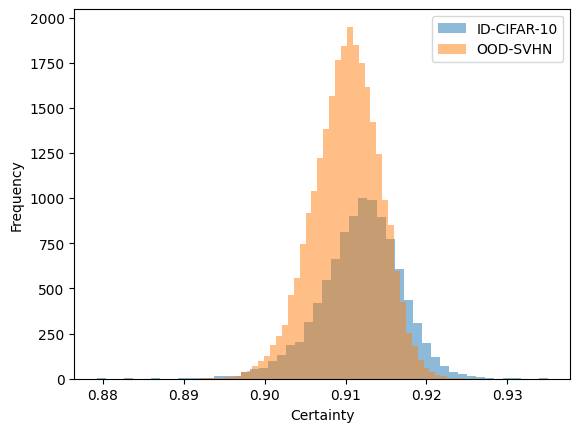

In [ ]:
# Строим графики:
import matplotlib.pyplot as plt

plt.hist(certainty_id, bins=50, alpha=0.5, label="ID-CIFAR-10")
plt.hist(certainty_ood, bins=50, alpha=0.5, label="OOD-SVHN")
plt.xlabel("Certainty")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [10]:
# Работа с CIFAR10

from torchvision.datasets import CIFAR10
from torchvision import transforms
from torch.utils.data import random_split, DataLoader

# Определяем трансформации (такие же, как в CIFAR10DataModule)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Загружаем датасет CIFAR-10 вручную (train и test)
train_dataset = CIFAR10(root="data", train=True, download=True, transform=transform)
test_dataset = CIFAR10(root="data", train=False, download=True, transform=transform)

# Доля данных для валидации
val_split = 0.2  # 20% на валидацию

# Вычисляем размеры train и val
train_size = int((1 - val_split) * len(train_dataset))
val_size = len(train_dataset) - train_size

# Разбиваем dataset на train и val с фиксированным seed (чтобы разбиение было всегда одинаковым)
generator = torch.Generator().manual_seed(42)  # Фиксируем seed для воспроизводимости
train_subset, val_subset = random_split(train_dataset, [train_size, val_size], generator=generator)


# Создаём DataLoaders
train_dataloader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_dataloader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

# Проверяем размеры датасетов
print(f"Train size: {len(train_subset)}, Validation size: {len(val_subset)}, Test size: {len(test_dataset)}")


Files already downloaded and verified
Files already downloaded and verified
Train size: 40000, Validation size: 10000, Test size: 10000


In [11]:
# Класс для Температурного масштабирования
import torch.nn as nn

class TemperatureScaling(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)  # Начальное значение T=1.5

    def forward(self, logits):
        T = torch.clamp(self.temperature, min=0.5, max=5.0)  # Ограничиваем диапазон T
        return logits / T

def train_temperature_scaling(model, val_loader):
    """ Подбор параметра T для temperature scaling """
    model.eval()
    ts_model = TemperatureScaling().to(device)

    optimizer = torch.optim.LBFGS([ts_model.temperature], lr=0.01, max_iter=50)  # Метод L-BFGS хорошо подходит для оптимизации T

    def closure():
        optimizer.zero_grad()
        logits_list, labels_list = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                logits = model(inputs)[:, :-1]  # Отбрасываем log_std, если он есть
                logits_list.append(logits)
                labels_list.append(labels)

        logits = torch.cat(logits_list)
        labels = torch.cat(labels_list)

        loss = nn.CrossEntropyLoss()(ts_model(logits), labels)
        loss.backward()
        return loss

    optimizer.step(closure)
    return ts_model


In [12]:
# Добучение с использованием температурного масштабирования

# Определяем устройство (GPU или CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Перемещаем модель на устройство
model_cs = model_cs.to(device)

ts_model = train_temperature_scaling(model_cs, val_dataloader)
print(f"Оптимальное значение T после обучения: {ts_model.temperature.item():.4f}")

# Применяем temperature scaling к логитам перед softmax
with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        logits = model_cs(inputs)[:, :-1]
        scaled_logits = ts_model(logits)
        probs = torch.softmax(scaled_logits, dim=1)


Using device: cuda
Оптимальное значение T после обучения: 0.3580


In [28]:
# Применяем ts_model к тестовым данным
with torch.no_grad():
    logits_list, labels_list = [], []

    for inputs, labels in test_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        logits = model_cs(inputs)[:, :-1]  # Отбрасываем log_std
        scaled_logits = ts_model(logits)  # Применяем Temperature Scaling

        logits_list.append(scaled_logits)
        labels_list.append(labels)

# Объединяем все батчи
logits = torch.cat(logits_list, dim=0)
labels = torch.cat(labels_list, dim=0)


In [29]:
# Переносим logits и labels на устройство модели, если необходимо
# logits = logits.to(device)
# labels = labels.to(device)
print(f"logits shape: {logits.shape}, labels shape: {labels.shape}")
print(f"logits", logits)
print(f"labels", labels)

logits shape: torch.Size([10000, 10]), labels shape: torch.Size([10000])
logits tensor([[-4.7168e-02,  1.6997e-02, -2.5748e-02,  ..., -2.4552e-02,
         -4.5684e-02,  6.3606e-03],
        [ 1.6098e-02, -1.2570e-01,  1.1061e-01,  ..., -1.8094e-02,
          1.9999e+00, -1.2845e-02],
        [ 1.5318e-01, -2.8417e-04,  2.1740e-01,  ..., -3.2845e-02,
          9.1511e-01,  3.8983e-02],
        ...,
        [-3.4408e-02, -3.4905e-03,  1.6449e-02,  ...,  3.0151e-03,
          4.2956e-02,  2.6418e-02],
        [-4.7144e-02,  1.9342e+00,  2.6137e-02,  ...,  6.0570e-02,
         -5.6785e-02, -3.7306e-01],
        [-1.0187e-02,  1.3766e-02, -3.1105e-02,  ...,  1.7401e+00,
          4.4190e-02, -3.3276e-02]], device='cuda:0')
labels tensor([3, 8, 8,  ..., 5, 1, 7], device='cuda:0')


In [30]:
# Функция подсчёта Expected Calibration Error

def compute_ece(logits, labels, n_bins=10, device="cuda"):
    probs = torch.softmax(logits.to(device), dim=1)  # Переносим logits
    max_probs, preds = torch.max(probs, dim=1)
    accuracy = (preds == labels.to(device)).float()  # Переносим labels

    bin_boundaries = torch.linspace(0, 1, n_bins + 1, device=device)  # Переносим bin_boundaries
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    ece = torch.tensor(0.0, device=device)  # Переносим ece на устройство

    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (max_probs >= bin_lower) & (max_probs < bin_upper)
        if in_bin.sum() == 0:
            continue

        avg_confidence = max_probs[in_bin].mean()
        avg_accuracy = accuracy[in_bin].mean()

        ece += torch.abs(avg_confidence - avg_accuracy) * in_bin.float().mean()

    return ece.item()  # Преобразуем в скаляр

In [31]:
# ECE до Temperature Scaling
ece_before = compute_ece(logits, labels)

# ECE после Temperature Scaling
ece_after = compute_ece(ts_model(logits), labels)

print(f"ECE до TS: {ece_before:.4f}")
print(f"ECE после TS: {ece_after:.4f}")

ECE до TS: 0.4725
ECE после TS: 0.1469


Reliability Diagram до Temperature Scaling:


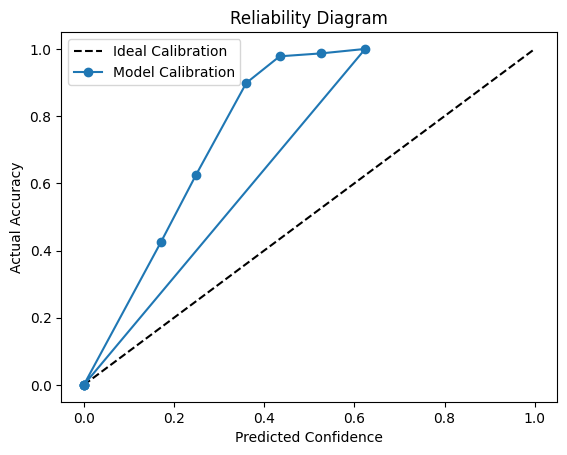

Reliability Diagram после Temperature Scaling:


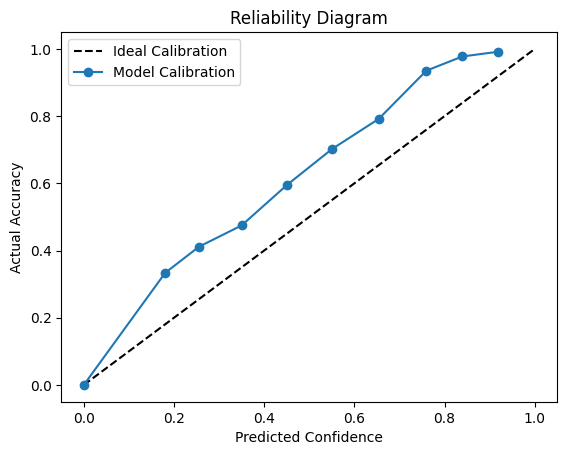

In [32]:
# Reliability Diagram (График калибровки)
import matplotlib.pyplot as plt

def reliability_diagram(logits, labels, n_bins=10):
    probs = torch.softmax(logits, dim=1)
    max_probs, preds = torch.max(probs, dim=1)
    accuracy = (preds == labels).float()

    bin_boundaries = torch.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_boundaries[:-1] + bin_boundaries[1:]) / 2

    avg_confidence = []
    avg_accuracy = []

    for bin_lower, bin_upper in zip(bin_boundaries[:-1], bin_boundaries[1:]):
        in_bin = (max_probs >= bin_lower) & (max_probs < bin_upper)
        if in_bin.sum() == 0:
            avg_confidence.append(0)
            avg_accuracy.append(0)
        else:
            avg_confidence.append(max_probs[in_bin].mean().item())
            avg_accuracy.append(accuracy[in_bin].mean().item())

    plt.plot([0, 1], [0, 1], "k--", label="Ideal Calibration")
    plt.plot(avg_confidence, avg_accuracy, marker="o", label="Model Calibration")
    plt.xlabel("Predicted Confidence")
    plt.ylabel("Actual Accuracy")
    plt.title("Reliability Diagram")
    plt.legend()
    plt.show()

# График до Temperature Scaling
print("Reliability Diagram до Temperature Scaling:")
reliability_diagram(logits, labels)

# График после Temperature Scaling
print("Reliability Diagram после Temperature Scaling:")
reliability_diagram(ts_model(logits), labels)


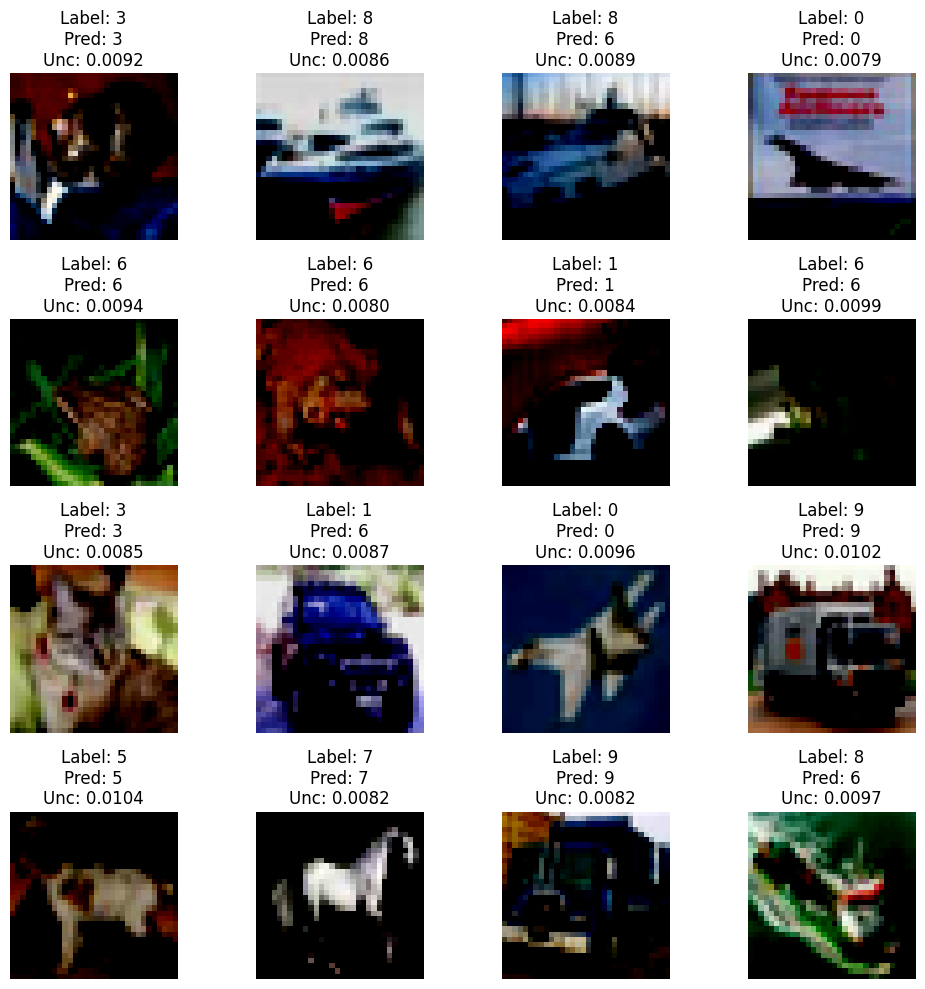

In [36]:
# Визуализация предсказаний
# Функция для обратной нормализации
def denormalize(tensor):
    return tensor * 0.5 + 0.5  # Обратно к [0,1]

# Получаем batch из test_dataloader
images, labels = next(iter(test_dataloader))

# Переключаем модель в режим оценки
model_cs.eval()

# Прогоняем изображения через модель
with torch.no_grad():
    preds = model_cs(images.to(device))  # Переносим на device, если модель на GPU

# Визуализация изображений и предсказаний
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
axes = axes.ravel()

for i in range(min(16, len(images))):
    img = images[i].cpu().permute(1, 2, 0).numpy()  # Переводим на CPU и меняем оси
    label = labels[i].item()
    pred = preds[i][:num_classes].argmax().item()
    uncertainty = torch.sigmoid(preds[i][num_classes:]).item()

    axes[i].imshow(img)
    axes[i].set_title(f"Label: {label}\nPred: {pred}\nUnc: {uncertainty:.4f}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


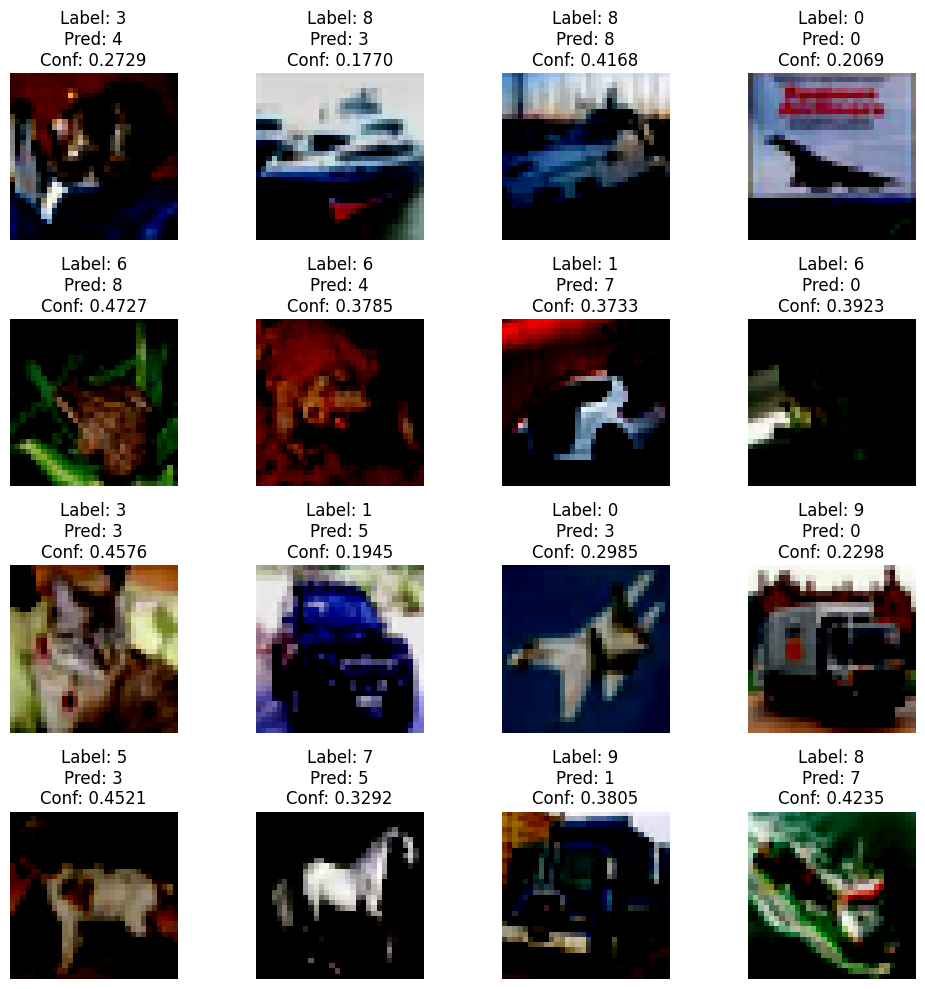

In [38]:
# Визуализация для ts_model
# Функция для обратной нормализации
def denormalize(tensor):
    return tensor * 0.5 + 0.5  # Обратно к [0,1]

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
axes = axes.ravel()

# Переводим данные на CPU (если они на GPU)
probs = probs.cpu()
labels = labels.cpu()

# Берём первые 16 изображений из test_dataset
for i in range(min(16, len(probs))):
    img = test_dataset[i][0].permute(1, 2, 0).numpy()  # Достаём изображение
    label = labels[i].item()  # Истинный класс
    pred = probs[i].argmax().item()  # Предсказанный класс
    confidence = probs[i].max().item()  # Уверенность в предсказании

    axes[i].imshow(img)
    axes[i].set_title(f"Label: {label}\nPred: {pred}\nConf: {confidence:.4f}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Формирование CSV файла с результатами экспериментов (метрики)
csvs = []
for folder in os.listdir('lightning_logs'):
    csvs.append(pd.read_csv(f'lightning_logs/{folder}/results.csv'))

results = pd.concat(csvs)
results.T